# iPhone Sales Analysis Project

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load Dataset

df = pd.read_csv("iphone_sales_dataset_realistic_upc.csv")

#print(df)

In [4]:
# Display first rows

print("First 5 Rows")
print(df.head())

print("Last 5 Rows")
print(df.tail())

First 5 Rows
   order_id  brand       product_name   ram          upc  original_price  \
0    100000  Apple          iPhone 11  6 GB  MOBQVH894R9           39999   
1    100001  Apple  iPhone 11 Pro Max  8 GB  MOB2QXVGPPZ           74999   
2    100002  Apple          iPhone 13  8 GB  MOBJNWBFM8V           59999   
3    100003  Apple  iPhone 14 Pro Max  6 GB  MOB7WOHQJEX          129999   
4    100004  Apple     iPhone 15 Plus  8 GB  MOB7T2SR2UJ           89999   

   discount_percent  final_price  rating  reviews_count  quantity_sold  \
0                 8        36799     4.4            612              3   
1                 0        74999     4.8           3122              1   
2                 6        56399     4.5           1958              4   
3                16       109199     4.1           2623              3   
4                 2        88199     4.6           4879              2   

        city  order_date                                      purchase_link  
0    Ch

In [5]:
# Dataset Information

print("\nDataset Info")
print(df.info())



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          800 non-null    int64  
 1   brand             800 non-null    object 
 2   product_name      800 non-null    object 
 3   ram               800 non-null    object 
 4   upc               800 non-null    object 
 5   original_price    800 non-null    int64  
 6   discount_percent  800 non-null    int64  
 7   final_price       800 non-null    int64  
 8   rating            800 non-null    float64
 9   reviews_count     800 non-null    int64  
 10  quantity_sold     800 non-null    int64  
 11  city              800 non-null    object 
 12  order_date        800 non-null    object 
 13  purchase_link     800 non-null    object 
dtypes: float64(1), int64(6), object(7)
memory usage: 87.6+ KB
None


In [6]:
# Check Null Values

print("\nMissing Values")
print(df.isnull().sum())


Missing Values
order_id            0
brand               0
product_name        0
ram                 0
upc                 0
original_price      0
discount_percent    0
final_price         0
rating              0
reviews_count       0
quantity_sold       0
city                0
order_date          0
purchase_link       0
dtype: int64


In [ ]:
# Remove Duplicates

df = df.drop_duplicates()

In [7]:
# Create Revenue Column

df["revenue"] = df["final_price"] * df["quantity_sold"]

print("\nRevenue Column Added")
print(df.head())


Revenue Column Added
   order_id  brand       product_name   ram          upc  original_price  \
0    100000  Apple          iPhone 11  6 GB  MOBQVH894R9           39999   
1    100001  Apple  iPhone 11 Pro Max  8 GB  MOB2QXVGPPZ           74999   
2    100002  Apple          iPhone 13  8 GB  MOBJNWBFM8V           59999   
3    100003  Apple  iPhone 14 Pro Max  6 GB  MOB7WOHQJEX          129999   
4    100004  Apple     iPhone 15 Plus  8 GB  MOB7T2SR2UJ           89999   

   discount_percent  final_price  rating  reviews_count  quantity_sold  \
0                 8        36799     4.4            612              3   
1                 0        74999     4.8           3122              1   
2                 6        56399     4.5           1958              4   
3                16       109199     4.1           2623              3   
4                 2        88199     4.6           4879              2   

        city  order_date                                      purchase_link 

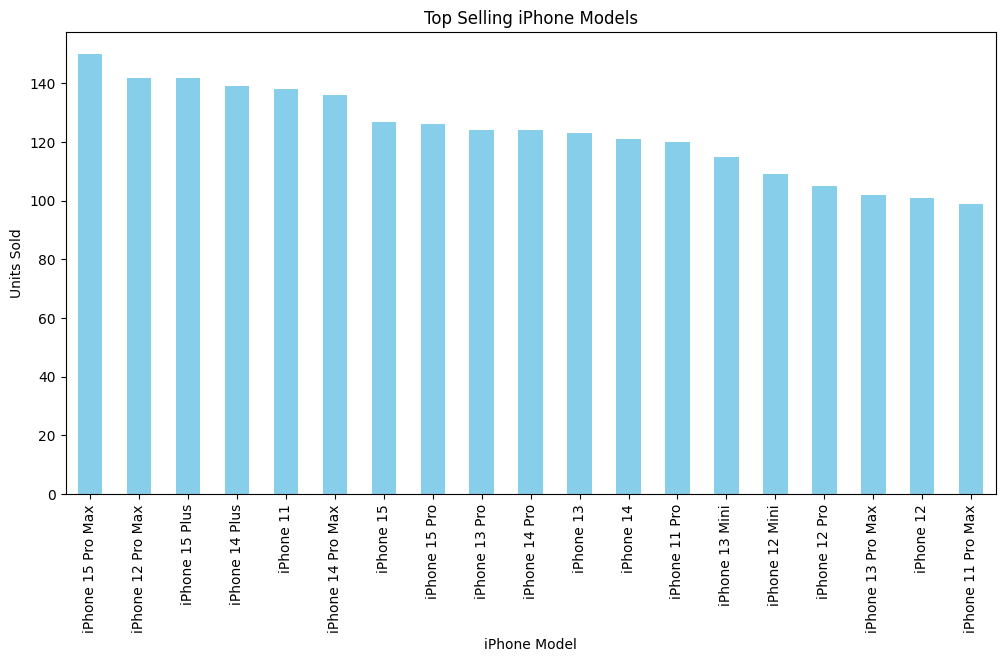

In [8]:
top_models = df.groupby("product_name")["quantity_sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
top_models.plot(kind="bar", color="skyblue")

plt.title("Top Selling iPhone Models")
plt.xlabel("iPhone Model")
plt.ylabel("Units Sold")

plt.show()

# Top Selling iPhone Models


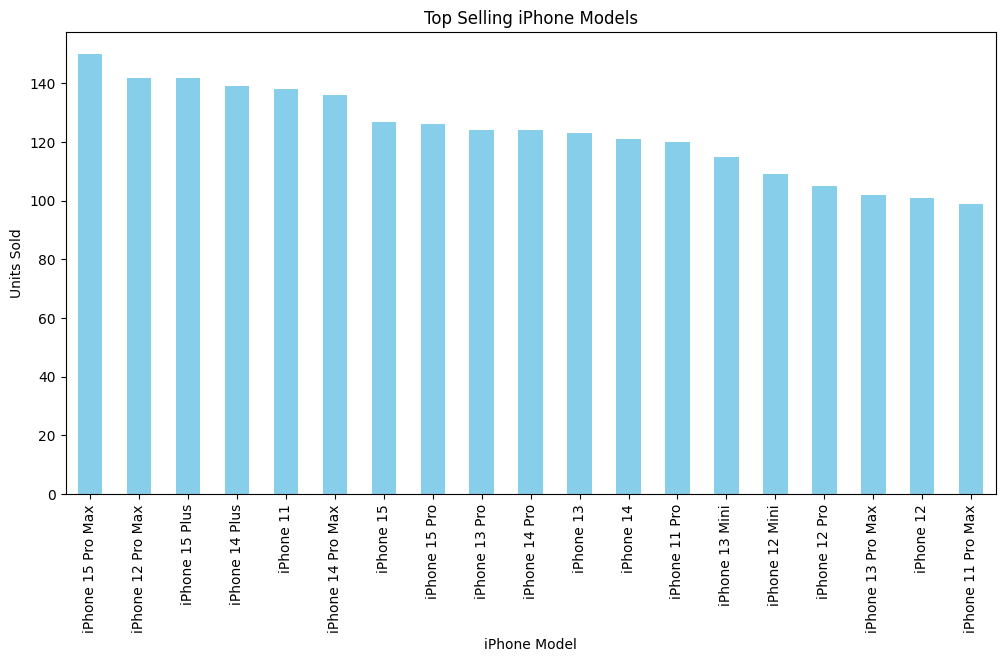

In [9]:
top_models = df.groupby("product_name")["quantity_sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
top_models.plot(kind="bar", color="skyblue")

plt.title("Top Selling iPhone Models")
plt.xlabel("iPhone Model")
plt.ylabel("Units Sold")

plt.show()

# Revenue by City


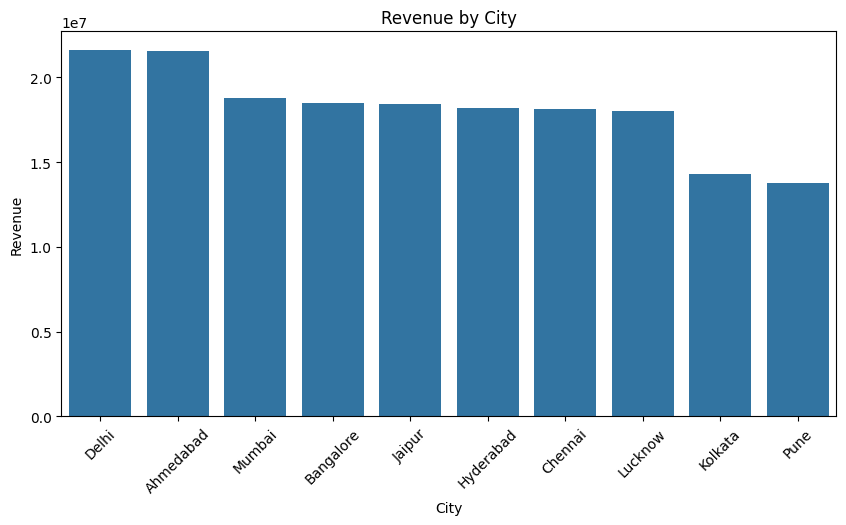

In [10]:
city_sales = df.groupby("city")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(x=city_sales.index, y=city_sales.values)

plt.title("Revenue by City")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

# Rating vs Quantity Sold


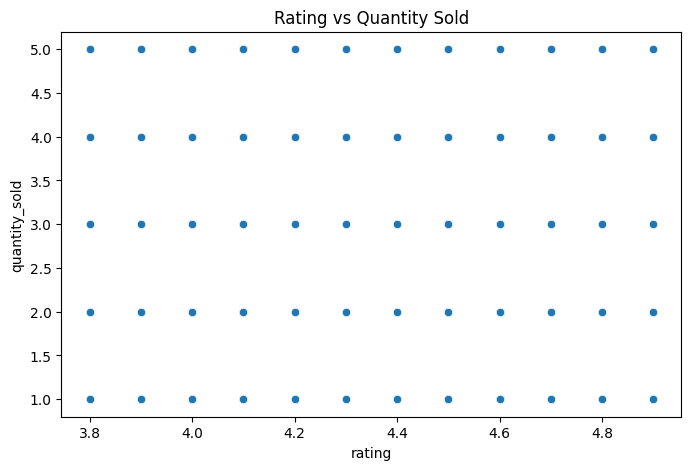

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="rating",
    y="quantity_sold"
)

plt.title("Rating vs Quantity Sold")

plt.show()

# Discount vs Sales


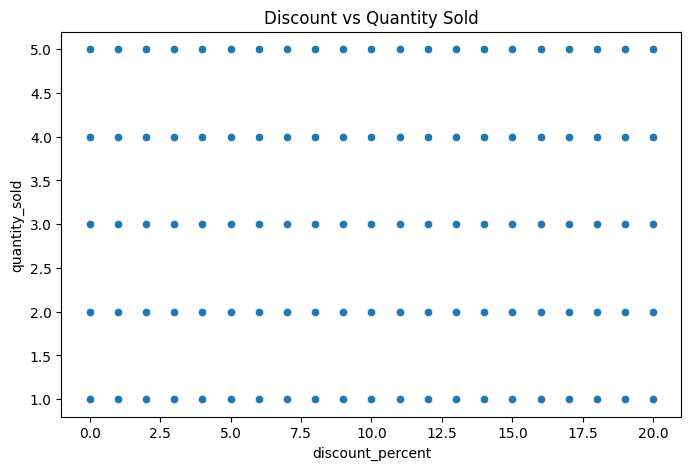

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="discount_percent",
    y="quantity_sold"
)

plt.title("Discount vs Quantity Sold")

plt.show()

# Monthly Revenue Trend


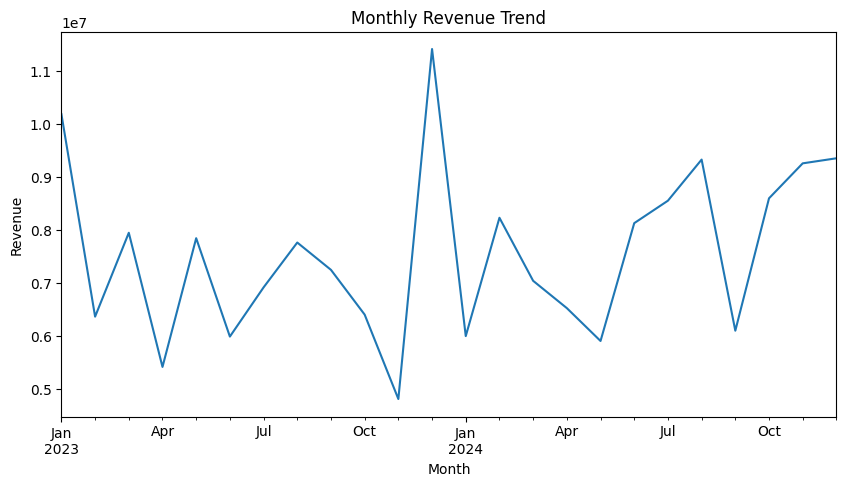

In [13]:
df["order_date"] = pd.to_datetime(df["order_date"])

df["month"] = df["order_date"].dt.to_period("M")

monthly_sales = df.groupby("month")["revenue"].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

# Correlation Heatmap


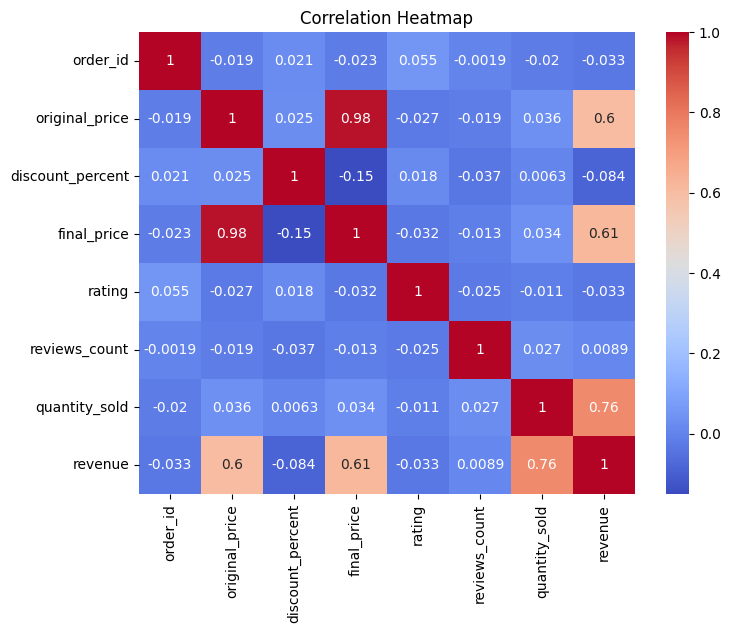

In [14]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()